In [1]:
!pip install -q kagglehub
import kagglehub
path = kagglehub.dataset_download("sshubam/insat3d-infrared-raw-cyclone-images-20132021")
print(path)

100%|██████████| 43.2M/43.2M [00:00<00:00, 144MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/sshubam/insat3d-infrared-raw-cyclone-images-20132021/versions/1


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
DEST = '/content/drive/MyDrive/cyclone_prototype/insat3d_data'
os.makedirs(DEST, exist_ok=True)
shutil.copytree(path, DEST, dirs_exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/cyclone_prototype/insat3d_data'

In [9]:
!cp -r "/content/drive/MyDrive/SIH_Cyclone_Project/insat3d_data" /content/data

In [10]:
import os

DATA_DIR = '/content/data'
for cls in sorted(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))} images")

insat3d_for_reference_ds: 1 images
insat3d_ir_cyclone_ds: 1 images
insat3d_raw_cyclone_ds: 1 images


In [11]:
import pandas as pd, os

df = pd.read_csv('/content/data/insat_3d_ds - Sheet.csv')

def wind_to_category(wind_kt):
    if wind_kt < 34: return 'Depression'
    elif wind_kt < 48: return 'CS'
    elif wind_kt < 64: return 'SCS'
    elif wind_kt < 90: return 'VSCS'
    elif wind_kt < 120: return 'ESCS'
    else: return 'SuCS'

df['category'] = df['label'].apply(wind_to_category)
df['category'] = df['category'].replace('SuCS', 'ESCS')

def to_3class(cat):
    if cat in ['Depression', 'CS']: return 'Low'
    elif cat == 'SCS': return 'Moderate'
    else: return 'High'

df['category'] = df['category'].apply(to_3class)

IR_DIR = '/content/data/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED'
def find_image_path(img_name):
    base = os.path.splitext(img_name)[0]
    for ext in ['.jpg', '.jpeg']:
        c = os.path.join(IR_DIR, base + ext)
        if os.path.exists(c): return c
    return None

df['filepath'] = df['img_name'].apply(find_image_path)
df = df.dropna(subset=['filepath'])
print(df['category'].value_counts())

category
Low         50
High        45
Moderate    41
Name: count, dtype: int64


In [12]:
import shutil
SORTED_DIR = '/content/data_sorted_3class'
for _, row in df.iterrows():
    cls_dir = os.path.join(SORTED_DIR, row['category'])
    os.makedirs(cls_dir, exist_ok=True)
    shutil.copy(row['filepath'], os.path.join(cls_dir, row['img_name']))

In [13]:
import tensorflow as tf

DATA_DIR = SORTED_DIR
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='training', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='validation', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE
norm = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x,y: (norm(x), y)).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x,y: (norm(x), y)).cache().prefetch(AUTOTUNE)

Found 136 files belonging to 3 classes.
Using 109 files for training.
Found 136 files belonging to 3 classes.
Using 27 files for validation.
['High', 'Low', 'Moderate']


In [27]:
tf.random.set_seed(42)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

NUM_CLASSES = len(class_names)
base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = True
for layer in base.layers[:-5]:
    layer.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []
for i, cls in enumerate(sorted(os.listdir(DATA_DIR))):
    labels += [i] * len(os.listdir(os.path.join(DATA_DIR, cls)))
class_weight_dict = dict(enumerate(compute_class_weight('balanced', classes=np.unique(labels), y=labels)))
print(class_weight_dict)

{0: np.float64(1.0074074074074073), 1: np.float64(0.9066666666666666), 2: np.float64(1.1056910569105691)}


In [33]:
class_weight_dict_boosted = {
    0: class_weight_dict[0] * 1,  # High
    1: class_weight_dict[1] * 1,  # Low
    2: class_weight_dict[2] * 1  # Moderate
}
print(class_weight_dict_boosted)

{0: np.float64(1.0074074074074073), 1: np.float64(0.9066666666666666), 2: np.float64(1.1056910569105691)}


In [34]:
CHECKPOINT_DIR = '/content/drive/MyDrive/SIH_Cyclone_Project/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'final_model_v2.keras')

callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max')
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

history = model.fit(train_ds, validation_data=val_ds, epochs=40,
                     class_weight=class_weight_dict_boosted, callbacks=[callback, early_stop])
model.save(checkpoint_path)
print("Saved:", checkpoint_path)

Epoch 1/40


7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.3853 - loss: 1.1937 - val_accuracy: 0.2963 - val_loss: 1.1175
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.4128 - loss: 1.1151 - val_accuracy: 0.2963 - val_loss: 1.1157
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.4312 - loss: 1.0890 - val_accuracy: 0.2593 - val_loss: 1.1135
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.4128 - loss: 1.1322 - val_accuracy: 0.2963 - val_loss: 1.1111
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.3945 - loss: 1.1023 - val_accuracy: 0.2963 - val_loss: 1.1089
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.3853 - loss: 1.1073 - val_accuracy: 0.3704 - val_loss: 1.1065
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.4220 - loss: 1.0561 - val_accuracy: 0.3704 - val_loss: 1.1042
Epoch 8/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.4037 - loss: 1.0843 - val_accuracy: 0.4074 - val_loss: 1.1020
Epoch 9/40
7/7 ━━━━

In [35]:
model = tf.keras.models.load_model('/content/drive/MyDrive/SIH_Cyclone_Project/checkpoints/final_model_v2.keras')
print(model.evaluate(val_ds))

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4074 - loss: 1.0625
[1.0625109672546387, 0.40740740299224854]


In [36]:
!ls -la "/content/drive/MyDrive/SIH_Cyclone_Project/checkpoints/"

total 312327
-rw------- 1 root root 106604425 Sep  3 16:05 best_model.keras
-rw------- 1 root root 106620074 Sep  4 10:44 final_model_augmented.keras
-rw------- 1 root root 106597839 Sep  4 12:13 final_model_v2.keras


grad cam


In [41]:
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block3_out'):
    resnet = model.layers[0]  # always the first layer regardless of naming
    grad_model = tf.keras.models.Model(
        inputs=resnet.input,
        outputs=[resnet.get_layer(last_conv_layer_name).output, resnet.output]
    )

    with tf.GradientTape() as tape:
        conv_output, resnet_output = grad_model(img_array)
        x = resnet_output
        for layer in model.layers[1:]:  # apply every layer after resnet50, in order
            x = layer(x)
        predictions = x
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), pred_index.numpy()

True: Moderate | Predicted: High


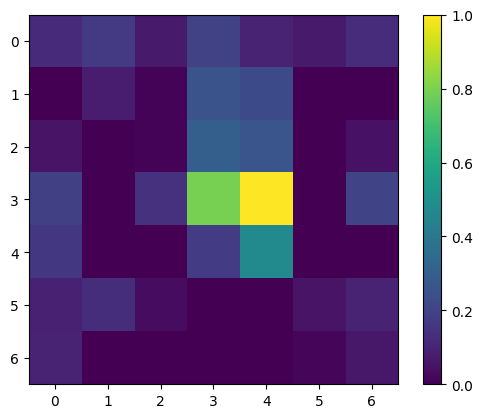

In [43]:
for images, labels in val_ds.take(1):
    sample_img = images[0:1]
    true_label = labels[0].numpy()
    break

heatmap, pred_class = make_gradcam_heatmap(sample_img, model)
print("True:", class_names[true_label], "| Predicted:", class_names[pred_class])

plt.imshow(heatmap)
plt.colorbar()
plt.show()

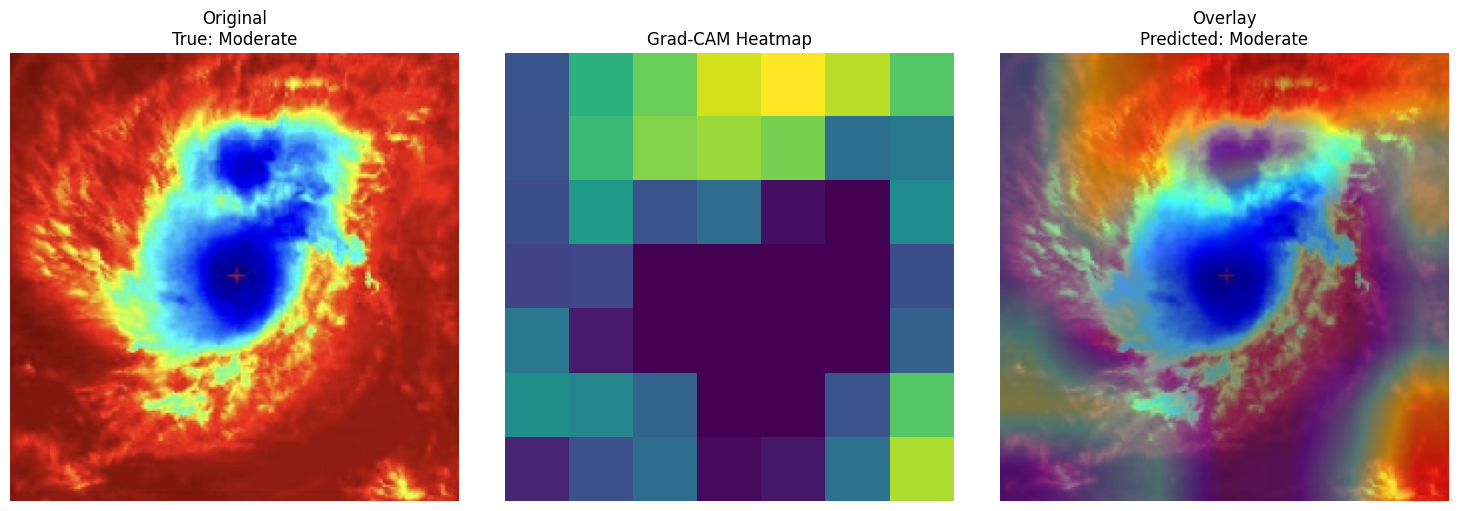

In [22]:
import cv2

def display_gradcam_overlay(img_array, heatmap, alpha=0.4):
    # img_array is normalized (0-1) — convert back to 0-255 for display
    img = np.uint8(255 * img_array[0])

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    overlayed = heatmap_colored * alpha + img * (1 - alpha)
    overlayed = np.uint8(overlayed)
    return overlayed

# Run on the same sample
overlay_img = display_gradcam_overlay(sample_img.numpy(), heatmap)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_img[0].numpy())
axes[0].set_title(f'Original\nTrue: {class_names[true_label]}')
axes[0].axis('off')

axes[1].imshow(heatmap)
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')

axes[2].imshow(overlay_img)
axes[2].set_title(f'Overlay\nPredicted: {class_names[pred_class]}')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/gradcam_sample1.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
samples_shown = 0
for images, labels in val_ds.take(3):
    for i in range(len(images)):
        if samples_shown >= 3:
            break
        img = images[i:i+1]
        label = labels[i].numpy()
        hm, pred = make_gradcam_heatmap(img, model)
        overlay = display_gradcam_overlay(img.numpy(), hm)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img[0].numpy()); axes[0].set_title(f'True: {class_names[label]}'); axes[0].axis('off')
        axes[1].imshow(hm); axes[1].set_title('Heatmap'); axes[1].axis('off')
        axes[2].imshow(overlay); axes[2].set_title(f'Pred: {class_names[pred]}'); axes[2].axis('off')
        plt.tight_layout()
        plt.savefig(f'/content/gradcam_sample_{samples_shown+2}.png', dpi=150, bbox_inches='tight')
        plt.show()
        samples_shown += 1
    if samples_shown >= 3:
        break

Output hidden; open in https://colab.research.google.com to view.

In [44]:
samples_by_class = {}

for images, labels in val_ds.unbatch():
    label = labels.numpy()
    cls_name = class_names[label]
    if cls_name not in samples_by_class:
        samples_by_class[cls_name] = images
    if len(samples_by_class) == len(class_names):
        break

print("Found samples for:", list(samples_by_class.keys()))

for i, (cls_name, img) in enumerate(samples_by_class.items()):
    img_batch = tf.expand_dims(img, axis=0)  # add batch dimension
    hm, pred = make_gradcam_heatmap(img_batch, model)
    overlay = display_gradcam_overlay(img_batch.numpy(), hm)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.numpy()); axes[0].set_title(f'True: {cls_name}'); axes[0].axis('off')
    axes[1].imshow(hm); axes[1].set_title('Heatmap'); axes[1].axis('off')
    axes[2].imshow(overlay); axes[2].set_title(f'Pred: {class_names[pred]}'); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'/content/gradcam_{cls_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for images, labels in val_ds.unbatch().batch(1):
    pred = model.predict(images, verbose=0)
    y_pred.append(np.argmax(pred))
    y_true.append(labels.numpy()[0])

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

        High       0.40      1.00      0.57         8
         Low       0.50      0.12      0.20         8
    Moderate       0.40      0.18      0.25        11

    accuracy                           0.41        27
   macro avg       0.43      0.44      0.34        27
weighted avg       0.43      0.41      0.33        27

[[8 0 0]
 [4 1 3]
 [8 1 2]]


In [46]:
!git config --global user.email "meghnamnambiar@gmail.com"
!git config --global user.name "Meghna M Nambiar"

In [48]:
!git clone https://github.com/pranavhere2007-jpg/cyclone-project.git
%cd cyclone-project

fatal: destination path 'cyclone-project' already exists and is not an empty directory.
/content/cyclone-project


In [49]:
%cd /content/cyclone-project
!git pull   # make sure you have the latest version, in case anything changed
!ls -la

/content/cyclone-project
Already up to date.
total 16
drwxr-xr-x 4 root root 4096 Sep  4 12:34 .
drwxr-xr-x 1 root root 4096 Sep  4 12:34 ..
drwxr-xr-x 4 root root 4096 Sep  4 12:34 Cyclone
drwxr-xr-x 8 root root 4096 Sep  4 12:35 .git


In [50]:
!mkdir -p ml-model/gradcam_samples

In [54]:
!ls "/content/drive/MyDrive/SIH_Cyclone_Project/"

 checkpoints  'CNN model + grad-cam.ipynb'   insat3d_data   prototype_ps.ipynb


In [ ]:
!cp "/content/drive/MyDrive/SIH_Cyclone_Project/'.ipynb" ml-model/